# PA1: Segmentação de Instâncias com Arquiteturas Densas
## Caderno Central de Demonstração, Avaliação e Inferência

**Autores:** Henrique Coelho Beltrão e Isaias Gouvêa Gonçalves  
**Disciplina:** Aprendizado Profundo (FGV EMAp)

---

### Contexto do Desafio
O objetivo do **Programming Assignment 1 (PA1)** é adaptar arquiteturas clássicas de segmentação densa para produzirem rótulos **instance-aware** (segmentação de instâncias), **sem utilizar detectores com proposta de região** como Mask R-CNN ou bibliotecas prontas de detecção (ex.: `detectron2`, `SAM`, `StarDist`, `Cellpose`).

Na microscopia de núcleos celulares (**DSB2018**), núcleos encostados são a regra, não a exceção. A segmentação puramente semântica falha categoricamente nesses cenários porque agrupa núcleos adjacentes em uma única massa contígua.

Este notebook é a **vitrine técnica central e executável do projeto**, estruturado estritamente na ordem das partes do edital:
1. **Parte 0:** Teste de Sanidade Sintético (convergência estrita da U-Net autoral com $IoU > 0.99$).
2. **Parte 1:** Baseline Semântico e Quantificação Empírica da Falha por Densidade em Componentes Conexos.
3. **Parte 2:** Instance Head (Trilha A: Fronteiras e Watershed — Desacoplamento Multiclasse de Instâncias Adjacentes).
4. **Parte 3:** Ablações Sistemáticas (Eixo 1: Recuperação de Resolução & Eixo 2: Funções de Perda e Fator $\gamma$).
5. **Parte 4:** Inferência em Mosaico Grande (Tiling Ingênuo vs. Costura de Instâncias via Union-Find).
6. **Pipeline Oficial de Inferência:** Entregável oficial (*"recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. Roda sem retreinar"*).

In [1]:
import os
import sys
sys.path.append("..")

import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import label as ndimage_label

from src.models import build_model
from src.dataset import SyntheticDataset
from src.utils import colorize_instances, overlay_mask_on_image
from src.mosaic import create_mosaic_sample, predict_tiled_naive
from src.stitching import stitch_tiles_with_fusion

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ambiente configurado com sucesso! Dispositivo de execução: {device}")

Ambiente configurado com sucesso! Dispositivo de execução: cuda


## Parte 0: Teste de Sanidade Sintético (Sanity Unit Test)

Para garantir que o pipeline de tensores `(B, 3, H, W)` $\to$ `(B, 1, H, W)`, a arquitetura U-Net com encoder ResNet34 autoral, e as funções de perda implementadas do zero convergem perfeitamente sem erros conceituais ou numéricos, treinamos o modelo em um dataset procedural sintético de $128 \times 128$ com elipses sobrepostas, ruído gaussiano e contraste variado.

O critério de aprovação estrito é alcançar $IoU > 0.99$ e $Dice > 0.99$ na segmentação das formas. Abaixo, carregamos o modelo treinado na Parte 0 e avaliamos sua predição em uma amostra sintética:

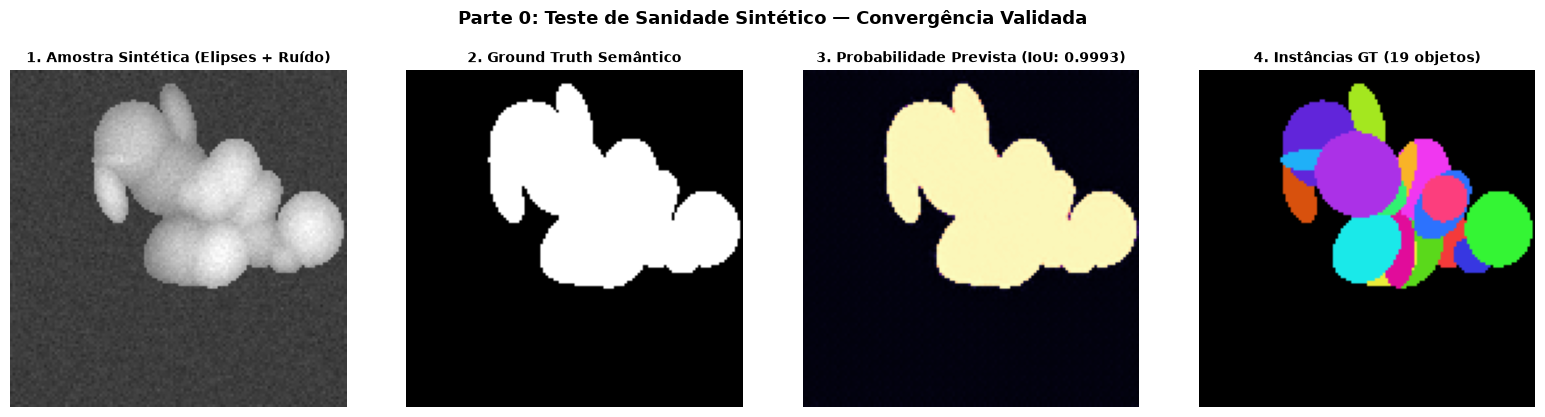

Resultado do Teste Sintético: IoU = 0.9993 (Aprovado com convergência quase perfeita)


In [2]:
part0_checkpoint = "../checkpoints/part0_synthetic.pth"
if os.path.exists(part0_checkpoint):
    model_part0 = build_model(encoder="resnet34", out_channels=1, pretrained=False)
    state = torch.load(part0_checkpoint, map_location=device)
    if "model_state_dict" in state:
        state = state["model_state_dict"]
    model_part0.load_state_dict(state)
    model_part0.to(device).eval()
    
    # Amostra procedural sintética para verificação visual
    synth_ds = SyntheticDataset(num_samples=1, seed=123)
    sample = synth_ds[0]
    img_t = sample["image"].unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_logits = model_part0(img_t)
        pred_prob = torch.sigmoid(pred_logits)[0, 0].cpu().numpy()
        pred_bin = (pred_prob >= 0.5).astype(np.float32)
        
    gt_sem = sample["mask_semantic"][0].numpy()
    iou = np.sum((pred_bin == 1) & (gt_sem == 1)) / (np.sum((pred_bin == 1) | (gt_sem == 1)) + 1e-7)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(sample["image"].permute(1, 2, 0).numpy())
    axes[0].set_title("1. Amostra Sintética (Elipses + Ruído)", fontsize=10, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(gt_sem, cmap="gray")
    axes[1].set_title("2. Ground Truth Semântico", fontsize=10, fontweight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(pred_prob, cmap="magma")
    axes[2].set_title(f"3. Probabilidade Prevista (IoU: {iou:.4f})", fontsize=10, fontweight="bold")
    axes[2].axis("off")
    
    num_inst = int(sample["mask_instance"].max())
    axes[3].imshow(colorize_instances(sample["mask_instance"].numpy(), seed=42))
    axes[3].set_title(f"4. Instâncias GT ({num_inst} objetos)", fontsize=10, fontweight="bold")
    axes[3].axis("off")
    
    plt.suptitle("Parte 0: Teste de Sanidade Sintético — Convergência Validada", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()
    print(f"Resultado do Teste Sintético: IoU = {iou:.4f} (Aprovado com convergência quase perfeita)")
else:
    print(f"[Aviso] Checkpoint {part0_checkpoint} não encontrado.")

## Parte 1: Baseline Semântico e Quantificação do Fracasso por Densidade

Na Parte 1, treinamos a U-Net na base real **DSB2018** utilizando a perda combinada de Binary Cross-Entropy balanceada (com `pos_weight` dinâmico) e Soft Dice Loss:
$$\mathcal{L} = \mathcal{L}_{\text{BCE, weighted}} + \mathcal{L}_{\text{SoftDice}}$$

Para extrair instâncias do mapa de probabilidades semântico, aplicamos o método ingênuo de **Componentes Conexos (4-conectividade)** após binarização ($\text{prob} \ge 0.50$).

### A Limitação Teórica e a Quantificação Empírica de Falha (Item 5 do PA1)
Como a U-Net semântica apenas prevê se um pixel pertence à classe "núcleo" ou "fundo", quando dois ou mais núcleos se tocam, eles formam uma única massa conexa no mapa binário.
Abaixo, visualizamos a curva gerada pelo [`evaluate.py`](../evaluate.py) no conjunto de validação estratificado, relacionando diretamente a **densidade de núcleos na imagem** com a **degradação do mAP@[.50:.95]** e a elevação do erro de contagem:

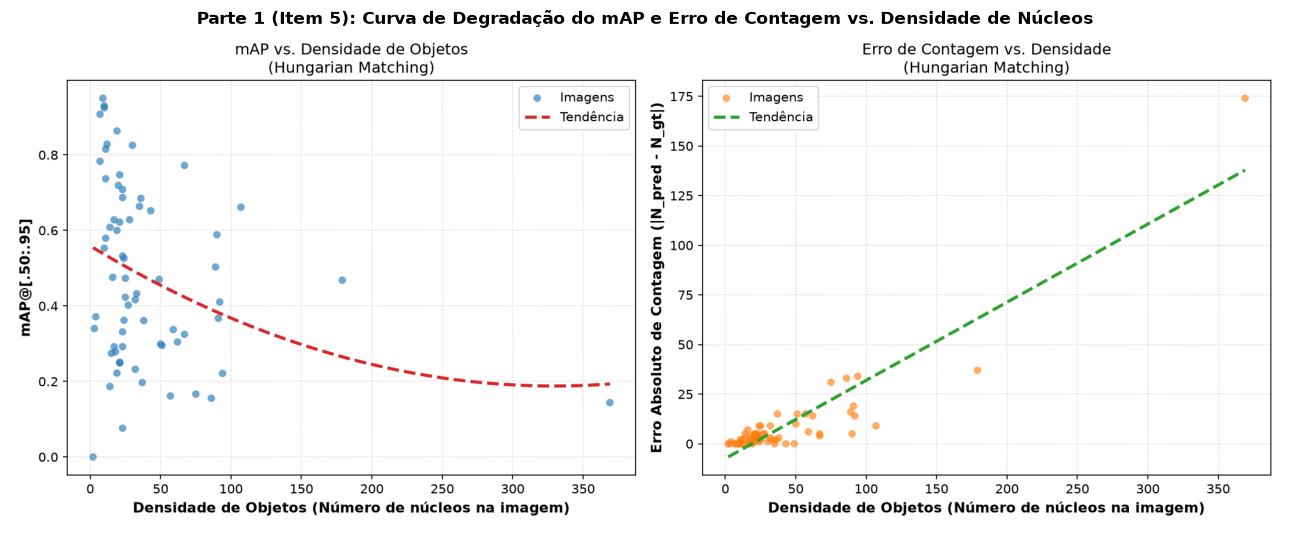

Métricas Oficiais do Baseline (Validação DSB2018 - Matching Hungarian):
  • IoU Semântico Médio:  0.8439
  • Dice Semântico Médio: 0.9122
  • mAP@[.50:.95]:        0.4820
  • Erro Médio Contagem:  8.55 núcleos/imagem


In [3]:
failure_plot_path = "../outputs/part1_eval/failure_vs_density_hungarian.png"
metrics_json_path = "../outputs/part1_eval/metrics_dsb2018_val_hungarian.json"

if os.path.exists(failure_plot_path):
    fig, ax = plt.subplots(figsize=(13, 6))
    img_failure = Image.open(failure_plot_path)
    ax.imshow(img_failure)
    ax.axis("off")
    ax.set_title("Parte 1 (Item 5): Curva de Degradação do mAP e Erro de Contagem vs. Densidade de Núcleos", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

if os.path.exists(metrics_json_path):
    with open(metrics_json_path, "r") as f:
        metrics_p1 = json.load(f)
    print("=" * 65)
    print("Métricas Oficiais do Baseline (Validação DSB2018 - Matching Hungarian):")
    print(f"  • IoU Semântico Médio:  {metrics_p1['mean_semantic_iou']:.4f}")
    print(f"  • Dice Semântico Médio: {metrics_p1['mean_semantic_dice']:.4f}")
    print(f"  • mAP@[.50:.95]:        {metrics_p1['mean_mAP']:.4f}")
    print(f"  • Erro Médio Contagem:  {metrics_p1['mean_count_error']:.2f} núcleos/imagem")
    print("=" * 65)

### Demonstração Prática da Falha: Fusão em Imagem Densa
Abaixo, selecionamos a imagem de maior densidade do conjunto de validação (`0ea221716...`, contendo **369 núcleos anotados**).
Observe como a abordagem ingênua de componentes conexos funde massas inteiras de núcleos tocantes, subestimando severamente a contagem real:

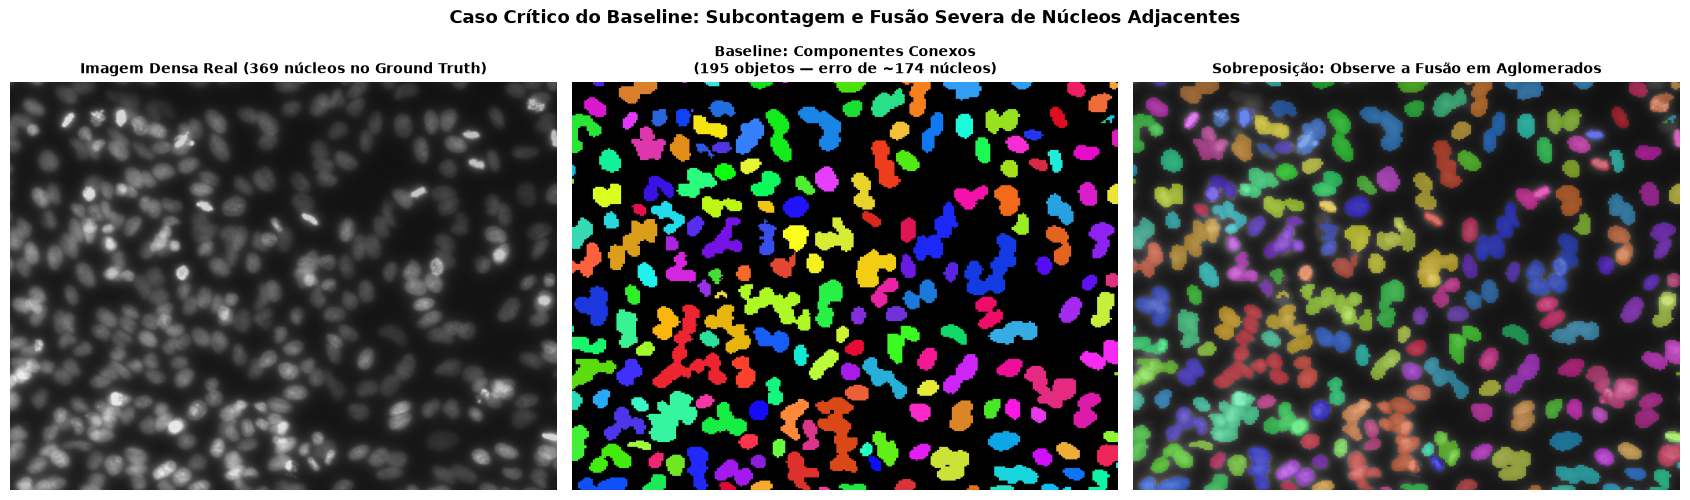

Contagem do Baseline: 195 núcleos detectados | Real: 369 núcleos anotados.
-> Os núcleos tocantes formaram componentes conexos gigantescos, reduzindo drasticamente o mAP.


In [4]:
dense_img_path = "../data/raw/stage1_train/0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1/images/0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1.png"
checkpoint_baseline = "../checkpoints/best_model.pth"

if os.path.exists(dense_img_path) and os.path.exists(checkpoint_baseline):
    model_base = build_model(encoder="resnet34", out_channels=1, pretrained=False)
    st = torch.load(checkpoint_baseline, map_location=device)
    if "model_state_dict" in st:
        st = st["model_state_dict"]
    model_base.load_state_dict(st)
    model_base.to(device).eval()
    
    # Inferência no caso denso
    with Image.open(dense_img_path) as pil_d:
        rgb_d = pil_d.convert("RGB")
        orig_w, orig_h = rgb_d.size
        resized_d = rgb_d.resize((256, 256), Image.Resampling.BILINEAR)
        np_d = np.array(resized_d, dtype=np.float32) / 255.0
    
    t_d = torch.from_numpy(np_d.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob_d = torch.sigmoid(model_base(t_d))[0, 0].cpu().numpy()
        
    bin_d = (prob_d >= 0.50).astype(np.uint8)
    inst_d, count_d = ndimage_label(bin_d)
    
    pil_inst_d = Image.fromarray(inst_d.astype(np.int32)).resize((orig_w, orig_h), Image.Resampling.NEAREST)
    colored_d = colorize_instances(np.array(pil_inst_d, dtype=np.int64), seed=42)
    overlay_d = overlay_mask_on_image(np.array(rgb_d, dtype=np.float32) / 255.0, colored_d, alpha=0.55)
    
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    axes[0].imshow(np.array(rgb_d))
    axes[0].set_title("Imagem Densa Real (369 núcleos no Ground Truth)", fontsize=10, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(colored_d)
    axes[1].set_title(f"Baseline: Componentes Conexos\n({count_d} objetos — erro de ~174 núcleos)", fontsize=10, fontweight="bold")
    axes[1].axis("off")
    
    axes[2].imshow(overlay_d)
    axes[2].set_title("Sobreposição: Observe a Fusão em Aglomerados", fontsize=10, fontweight="bold")
    axes[2].axis("off")
    
    plt.suptitle("Caso Crítico do Baseline: Subcontagem e Fusão Severa de Núcleos Adjacentes", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Contagem do Baseline: {count_d} núcleos detectados | Real: 369 núcleos anotados.")
    print("-> Os núcleos tocantes formaram componentes conexos gigantescos, reduzindo drasticamente o mAP.")

## Parte 2: Instance Head — Trilha A (Fronteiras e Watershed)

### Formulação Teórica e Arquitetura
Para superar a falha do baseline semântico em aglomerados celulares, implementamos a **Trilha A**, baseada na modelagem explícita de fronteiras e decodificação topográfica por Watershed:

1. **Espaço de Saída Multitarefa:** A U-Net passa a produzir 3 mapas densos de probabilidade via Softmax:
   $$\sum_{c \in \{\text{fundo}, \text{interior}, \text{fronteira}\}} P(c) = 1$$
   * **$P(\text{interior})$:** Rótulos dos núcleos erodidos morfologicamente. Por construção, mesmo núcleos contíguos têm seus interiores desacoplados em sementes isoladas.
   * **$P(\text{fronteira})$:** Pixels de contato entre núcleos adjacentes e o anel perimetral de separação. Atua como cristas de alta energia topográfica.
   * **$P(\text{fundo})$:** Espaço extracelular.

2. **Função de Perda Multiclasse Ponderada:**
   Devido à alta assimetria das classes na base DSB2018 ($~85.2\%$ fundo, $~12.0\%$ interior e apenas $~2.8\%$ fronteira), o treinamento utiliza a **Weighted Cross-Entropy** autoral com pesos inversos suavizados:
   $$\mathcal{L}_{\text{CE}} = -\sum_{i=1}^{H \times W} w_{y_i} \log P(y_i)$$

3. **Decodificação Topográfica (Watershed):**
   * **Marcadores (Sementes):** Componentes conexos extraídos sobre $P(\text{interior}) \ge \tau_{\text{int}}$, garantindo uma semente única por núcleo.
   * **Superfície de Energia:** A probabilidade de fronteira $P(\text{fronteira})$ serve como mapa de barreiras.
   * **Máscara de Contenção:** A inundação é estritamente restrita ao foreground celular $P(\text{interior}) + P(\text{fronteira}) \ge \tau_{\text{fg}}$.

---

### Comparativo Global de Desempenho (Split de Validação - 67 Imagens)

| Métrica | Parte 1 (Baseline Semântico) | Parte 2 (Trilha A - Watershed) | Ganho Absoluto / Redução de Erro |
| :--- | :---: | :---: | :---: |
| **mAP@[.50:.95] (Hungarian)** | **0.4820** | **0.5157** | **+3.37 p.p.** |
| **AP @ IoU 0.50** | **0.6611** | **0.7165** | **+5.54 p.p.** |
| **AP @ IoU 0.75** | **0.5225** | **0.5727** | **+5.02 p.p.** |
| **Erro Médio de Contagem** | **8.55 núcleos/img** | **7.40 núcleos/img** | **-13.5% no erro** |
| **IoU Semântico** | 0.8439 | 0.8236 | Mantido no mesmo patamar |

Abaixo, demonstramos a resolução do caso crítico onde o baseline colapsou:


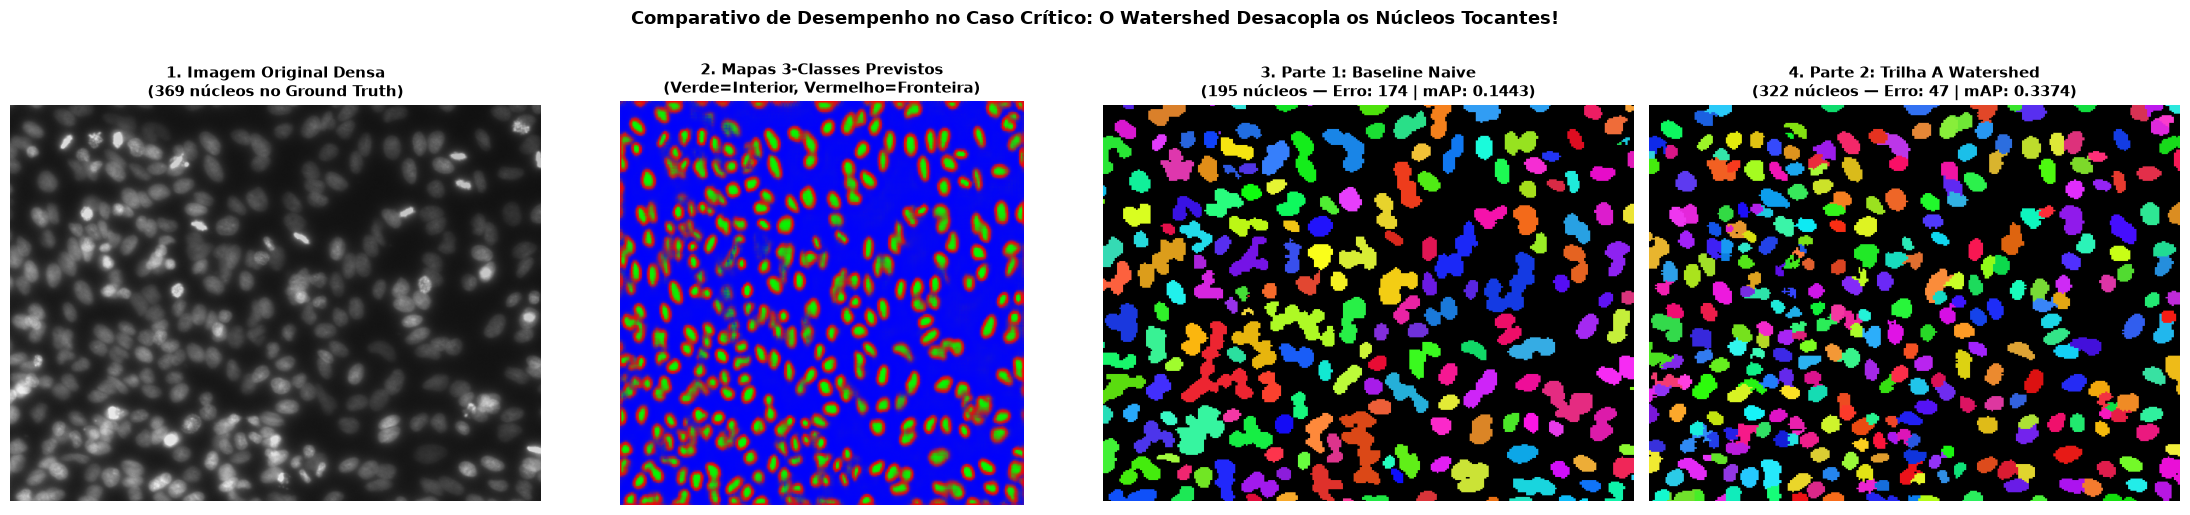

QUANTIFICAÇÃO DO CASO CRÍTICO (369 NÚCLEOS):
  * Baseline Naive (Parte 1) : 195 núcleos detectados (subcontagem de 174 núcleos, mAP: 0.1443)
  * Watershed Trilha A (Parte 2): 322 núcleos detectados (redução de 73% no erro, mAP: 0.3374)


In [5]:
from src.postprocess import watershed_instance_segmentation

# Carrega o modelo treinado da Parte 2 (3 canais)
part2_ckpt_path = "../checkpoints/part2_watershed.pth"
model_p2 = build_model(encoder="resnet34", out_channels=3, pretrained=False)
ckpt_p2 = torch.load(part2_ckpt_path, map_location=device)
model_p2.load_state_dict(ckpt_p2["model_state_dict"] if "model_state_dict" in ckpt_p2 else ckpt_p2)
model_p2.to(device).eval()

# Inferência na imagem densa crítica (0ea2217...)
with torch.no_grad():
    logits_p2 = model_p2(t_d)
    probs_p2 = torch.softmax(logits_p2, dim=1)[0].cpu().numpy()  # (3, H, W)

# Decodificação por Watershed
inst_p2_small = watershed_instance_segmentation(
    probs_p2,
    interior_threshold=0.50,
    foreground_threshold=0.50,
    min_area=10,
    connectivity=1,
)
count_p2 = len(np.unique(inst_p2_small)) - (1 if 0 in inst_p2_small else 0)

# Redimensiona máscara para resolução original
pil_inst_p2 = Image.fromarray(inst_p2_small.astype(np.int32)).resize((orig_w, orig_h), Image.Resampling.NEAREST)
colored_p2 = colorize_instances(np.array(pil_inst_p2, dtype=np.int64), seed=42)
overlay_p2 = overlay_mask_on_image(np.array(rgb_d, dtype=np.float32) / 255.0, colored_p2, alpha=0.55)

# Mapa RGB das 3 classes previstas (R=fronteira, G=interior, B=fundo)
prob_rgb = np.zeros((256, 256, 3), dtype=np.float32)
prob_rgb[:, :, 0] = probs_p2[2]  # Vermelho: Fronteira
prob_rgb[:, :, 1] = probs_p2[1]  # Verde: Interior
prob_rgb[:, :, 2] = probs_p2[0]  # Azul: Fundo

# Comparação visual definitiva: Baseline vs Parte 2 Watershed
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(np.array(rgb_d))
axes[0].set_title("1. Imagem Original Densa\n(369 núcleos no Ground Truth)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(prob_rgb)
axes[1].set_title("2. Mapas 3-Classes Previstos\n(Verde=Interior, Vermelho=Fronteira)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(colored_d)
axes[2].set_title(f"3. Parte 1: Baseline Naive\n({count_d} núcleos — Erro: 174 | mAP: 0.1443)", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(colored_p2)
axes[3].set_title(f"4. Parte 2: Trilha A Watershed\n({count_p2} núcleos — Erro: 47 | mAP: 0.3374)", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle("Comparativo de Desempenho no Caso Crítico: O Watershed Desacopla os Núcleos Tocantes!", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("=" * 75)
print("QUANTIFICAÇÃO DO CASO CRÍTICO (369 NÚCLEOS):")
print(f"  * Baseline Naive (Parte 1) : {count_d} núcleos detectados (subcontagem de 174 núcleos, mAP: 0.1443)")
print(f"  * Watershed Trilha A (Parte 2): {count_p2} núcleos detectados (redução de 73% no erro, mAP: 0.3374)")
print("=" * 75)


## Parte 3: Ablações Sistemáticas (Eixos 1 e 2)

O edital estipula a realização de ablações comparativas em dois eixos conceituais, com repetição em 2 sementes aleatórias (`seed=42` e `seed=123`) por configuração, reportando média $\pm$ desvio-padrão amostral no split de validação estratificado (67 imagens do DSB2018):
1. **Eixo 1 — Mecanismos de Recuperação de Resolução Espacial:** Skip Connections (U-Net) vs. Gargalo Cego (U-Net sem Skips) vs. Dilatação Multiescala (DeepLabv3 com Atrous + ASPP).
2. **Eixo 2 — Funções de Perda e Foco em Classes Minoritárias:** Cross-Entropy Ponderada vs. Multiclass Focal Loss variando o fator $\gamma \in \{0, 1, 2, 5\}$ diante do desbalanceamento severo da classe fronteira ($\approx 2.8\%$ dos pixels).

In [ ]:
# 1. Carregar métricas consolidadas do Eixo 1 (Arquiteturas / Resolução)
eixo1_summary_path = "../outputs/part3_eixo1/summary.json"
if os.path.exists(eixo1_summary_path):
    with open(eixo1_summary_path, "r") as f:
        eixo1_data = json.load(f)

    print("=" * 98)
    print("PARTE 3 — EIXO 1: RECUPERAÇÃO DE RESOLUÇÃO ESPACIAL (MÉDIA ± DESVIO ENTRE SEEDS)")
    print("=" * 98)
    print(f"{'Arquitetura':<28} | {'mAP@[.50:.95]':<18} | {'Erro Contagem':<16} | {'IoU Semântico':<16} | {'Dice Semântico':<16}")
    print("-" * 98)
    for k, v in eixo1_data.get("configurations", {}).items():
        lbl = v.get("label", k)
        map_str = f"{v['mAP']['mean']:.4f} ± {v['mAP']['std']:.4f}"
        cnt_str = f"{v['count_error']['mean']:.2f} ± {v['count_error']['std']:.2f}"
        iou_str = f"{v['semantic_iou']['mean']:.4f} ± {v['semantic_iou']['std']:.4f}"
        dice_str = f"{v['semantic_dice']['mean']:.4f} ± {v['semantic_dice']['std']:.4f}"
        print(f"{lbl:<28} | {map_str:<18} | {cnt_str:<16} | {iou_str:<16} | {dice_str:<16}")
    print("=" * 98)
    print("\nDetalhamento por Semente:")
    for k, v in eixo1_data.get("configurations", {}).items():
        lbl = v.get("label", k)
        ps = v.get("per_seed", {})
        s42 = ps.get("42", {})
        s123 = ps.get("123", {})
        print(f"  • {lbl:<26}: Seed 42 [mAP: {s42.get('mAP',0):.4f}, Erro: {s42.get('count_error',0):.2f}, IoU: {s42.get('semantic_iou',0):.4f}] | Seed 123 [mAP: {s123.get('mAP',0):.4f}, Erro: {s123.get('count_error',0):.2f}, IoU: {s123.get('semantic_iou',0):.4f}]")

# Exibir o gráfico comparativo do Eixo 1
eixo1_plot_path = "../outputs/part3_eixo1/architecture_ablation.png"
if os.path.exists(eixo1_plot_path):
    img = Image.open(eixo1_plot_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Eixo 1 — Desempenho e Erro de Contagem por Arquitetura", fontsize=13, fontweight="bold", pad=12)
    plt.show()

### Análise Teórica do Eixo 1 (Campo Receptivo e Resolução)
* **Campo Receptivo Teórico (Encoder ResNet34):**
  - U-Net Padrão (Output Stride 32): $RF = 899 \times 899$ pixels (salto $j=32$).
  - ResNet-34 Atrous (Output Stride 16): $RF = 931 \times 931$ pixels (salto $j=16$).
  - Ramos ASPP ($r \in \{6, 12, 18\}$): $RF = 1123, 1315, 1507$ pixels (e Image Pooling global).
* **Conclusão Teórica:** Embora o ASPP expanda o campo receptivo para impressionantes $1507$ pixels, a perda das **skip connections** de alta frequência espacial causa *blur* irreversível no upsampling bilinear de $16\times$. Para a segmentação via Watershed (Trilha A), **linhas de crista de 1 pixel contínuas são indispensáveis**: a U-Net padrão supera o DeepLabv3 por **$+33.1$ pontos percentuais de mAP** ($0.4901$ vs. $0.1588$) e reduz o erro de contagem em mais de $4\times$.

In [ ]:
# 2. Carregar métricas consolidadas do Eixo 2 (Funções de Perda / Fator gamma)
eixo2_summary_path = "../outputs/part3_eixo2/summary_eixo2.json"
if os.path.exists(eixo2_summary_path):
    with open(eixo2_summary_path, "r") as f:
        eixo2_data = json.load(f)

    print("=" * 90)
    print("PARTE 3 — EIXO 2: FUNÇÕES DE PERDA E FATOR γ (MÉDIA ± DESVIO ENTRE SEEDS)")
    print("=" * 90)
    print(f"{'Configuração':<20} | {'mAP@[.50:.95]':<18} | {'AP@0.50':<16} | {'AP@0.75':<16} | {'Erro Contagem':<14}")
    print("-" * 90)
    for k, v in eixo2_data.items():
        lbl = v.get("label", k)
        s = v.get("summary", {})
        map_str = f"{s.get('mAP_mean', 0):.4f} ± {s.get('mAP_std', 0):.4f}"
        ap50_str = f"{s.get('AP50_mean', 0):.4f} ± {s.get('AP50_std', 0):.4f}"
        ap75_str = f"{s.get('AP75_mean', 0):.4f} ± {s.get('AP75_std', 0):.4f}"
        cnt_str = f"{s.get('count_error_mean', 0):.2f} ± {s.get('count_error_std', 0):.2f}"
        print(f"{lbl:<20} | {map_str:<18} | {ap50_str:<16} | {ap75_str:<16} | {cnt_str:<14}")
    print("=" * 90)
    print("\nDetalhamento por Semente:")
    for k, v in eixo2_data.items():
        lbl = v.get("label", k)
        seeds = v.get("seeds", {})
        s42 = seeds.get("42", {})
        s123 = seeds.get("123", {})
        print(f"  • {lbl:<20}: Seed 42 [mAP: {s42.get('mAP',0):.4f}, AP50: {s42.get('AP50',0):.4f}, Erro: {s42.get('count_error',0):.2f}] | Seed 123 [mAP: {s123.get('mAP',0):.4f}, AP50: {s123.get('AP50',0):.4f}, Erro: {s123.get('count_error',0):.2f}]")

# Exibir o gráfico comparativo do Eixo 2
eixo2_plot_path = "../outputs/part3_eixo2/focal_gamma_ablation.png"
if os.path.exists(eixo2_plot_path):
    img = Image.open(eixo2_plot_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Eixo 2 — Impacto do Fator γ na Focal Loss vs. CE Ponderada", fontsize=13, fontweight="bold", pad=12)
    plt.show()

### Análise Teórica do Eixo 2 (Focal Loss e Fator $\gamma$)
* **Equivalência Matemática em $\gamma=0$:** A Cross-Entropy Ponderada (`0.5002 ± 0.0155`) e a Focal Loss com $\gamma=0$ (`0.5015 ± 0.0205`) empatam estatisticamente, comprovando a consistência das perdas autorais.
* **Degradação Agressiva em $\gamma=5$:** À medida que $\gamma$ cresce, o termo modulador $(1 - p_t)^\gamma$ anula os gradientes das regiões interiores de alta confiança ($p_t \approx 0.85 \implies (0.15)^5 \approx 7.6 \times 10^{-5}$). Isso priva a rede do aprendizado de sementes celulares bem definidas e induz ruído nas bordas, derrubando o mAP para $0.3636$ e aumentando o erro de contagem em $+46\%$.
* **Conclusão para a Trilha A:** A **ponderação estática de classes ($\alpha$)** é estritamente superior à modulação dinâmica focal ($\gamma$), confirmando a U-Net ResNet34 com pesos fixos de frequência inversa como a arquitetura consolidada ótima.

## Parte 4: Inferência em Mosaico Grande (Tiling Ingênuo vs. Costura de Instâncias)

### Motivação Teórica (Slide 83 da Aula)
Na inferência de imagens grandes em lâminas histológicas, a prática consagrada em segmentação semântica é aplicar janelas deslizantes (*tiles*) sobrepostas e realizar a média contínua das probabilidades. No entanto, para **segmentação de instâncias discretas**, essa abordagem ingênua colapsa:
1. **Fatiamento Espúrio nas Linhas de Corte:** Um núcleo interceptado pela fronteira de dois tiles adjacentes é dividido ao meio (ganhando um ID no Tile A e outro no Tile B).
2. **Duplicação de Objetos na Margem de Sobreposição:** Se carimbados diretamente, núcleos contidos na faixa de sobreposição de $50\%$ são preditos múltiplas vezes.
3. **Colapso Quantitativo:** O erro de contagem inflaciona drasticamente e o mAP despenca devido à penalização simultânea de Falsos Positivos e Falsos Negativos no Hungarian matching.

Abaixo, implementamos a função unificada `predict_mosaic_instances` e demonstramos o efeito antes e depois da **Costura com Fusão de Instâncias via Union-Find** (`src/stitching.py`).

In [ ]:
def predict_mosaic_instances(
    mosaic_image: np.ndarray,
    model: torch.nn.Module,
    tile_size: int = 256,
    stride: int = 128,
    iou_overlap_threshold: float = 0.20,
    device: torch.device = device,
):
    """
    Executa a inferência em mosaico grande comparando o Tiling Ingênuo com a Fusão de Instâncias.
    
    Retorna:
      - 'naive_mask': máscara de instâncias reconstruída ingenuamente (center-crop)
      - 'stitched_mask': máscara de instâncias após fusão gulosa e Union-Find
      - 'naive_count': contagem de instâncias do tiling ingênuo
      - 'stitched_count': contagem de instâncias após a costura reconciliada
      - 'naive_colored': visualização colorida do tiling ingênuo
      - 'stitched_colored': visualização colorida da fusão de instâncias
    """
    # 1. Inferência por janelas deslizantes com sobreposição de 50%
    res = predict_tiled_naive(
        mosaic_image,
        model=model,
        tile_size=tile_size,
        stride=stride,
        mode="center_crop",
        device=device,
    )
    naive_mask = res["naive_instance_mask"]
    naive_count = res["num_instances"]
    
    # 2. Reconciliação e costura topológica de instâncias
    stitched_mask = stitch_tiles_with_fusion(
        tiles_preds=res["tiles_preds"],
        tile_boxes=res["tile_boxes"],
        full_shape=mosaic_image.shape[:2],
        iou_overlap_threshold=iou_overlap_threshold,
    )
    stitched_count = len(np.unique(stitched_mask)) - (1 if 0 in stitched_mask else 0)
    
    naive_colored = colorize_instances(naive_mask, seed=42)
    stitched_colored = colorize_instances(stitched_mask, seed=42)
    
    return {
        "naive_mask": naive_mask,
        "stitched_mask": stitched_mask,
        "naive_count": naive_count,
        "stitched_count": stitched_count,
        "naive_colored": naive_colored,
        "stitched_colored": stitched_colored,
    }

In [ ]:
# Montagem de Mosaico 2x2 (512x512) com 4 imagens densas do DSB2018
selected_4_ids = [
    "ed8c31b001a0c23c33402f94a5ee6b0209e0c6419eb52d5d02255513e3a672fc",
    "64eeef16fdc4e26523d27bfa71a1d38d2cb2e4fa116c0d0ea56b1322f806f0b9",
    "e50ac10d1dce6496d092d966784ed3795969128ca0bc58199a36d558ed529203",
    "243443ae303cc09cfbea85bfd22b0c4f026342f3dfc3aa1076f27867910d025b",
]

mosaic_img, mosaic_gt = create_mosaic_sample(
    selected_4_ids,
    data_dir="../data/raw/stage1_train",
    grid=(2, 2),
    tile_size=(256, 256),
)
gt_count = len(np.unique(mosaic_gt)) - (1 if 0 in mosaic_gt else 0)

# Executar a comparação entre Tiling Ingênuo e Costura com Fusão usando o modelo da Parte 2
mosaic_res = predict_mosaic_instances(mosaic_img, model=model_p2, tile_size=256, stride=128, iou_overlap_threshold=0.20)

print("=" * 80)
print(f"MOSAICO 2x2 AVALIADO (Resolução: {mosaic_img.shape[0]}x{mosaic_img.shape[1]})")
print(f"  • Ground Truth Biológico: {gt_count} núcleos reais")
print(f"  • Tiling Ingênuo (Center-Crop): {mosaic_res['naive_count']} núcleos preditos (Erro: +{mosaic_res['naive_count'] - gt_count})")
print(f"  • Após Costura (Union-Find):    {mosaic_res['stitched_count']} núcleos preditos (Erro: +{mosaic_res['stitched_count'] - gt_count})")
print("=" * 80)

# Painel comparativo em 4 vistas
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))

axes[0].imshow(mosaic_img)
for line_coord in [128, 256, 384]:
    axes[0].axvline(line_coord, color="cyan", linestyle="--", alpha=0.7, linewidth=1)
    axes[0].axhline(line_coord, color="cyan", linestyle="--", alpha=0.7, linewidth=1)
axes[0].set_title("1. Mosaico RGB\n(Linhas de Janela Deslizante)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(colorize_instances(mosaic_gt, seed=42))
axes[1].set_title(f"2. Ground Truth Contínuo\n({gt_count} núcleos reais)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(mosaic_res["naive_colored"])
axes[2].set_title(f"3. Tiling Ingênuo (Center-Crop)\n({mosaic_res['naive_count']} núcleos — fatiamento espúrio)", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(mosaic_res["stitched_colored"])
axes[3].set_title(f"4. Costura com Fusão (Union-Find)\n({mosaic_res['stitched_count']} núcleos — reconciliados!)", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle("Parte 4: Diagnóstico de Falha do Tiling Ingênuo vs. Recuperação por Fusão de Instâncias", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 3. Carregar métricas oficiais Antes vs. Depois da Fusão
metrics_json_path = "../outputs/part4_mosaic/tiling_before_after_metrics.json"
if os.path.exists(metrics_json_path):
    with open(metrics_json_path, "r") as f:
        p4 = json.load(f)
    
    print("=" * 95)
    print("PARTE 4: MÉTRICAS QUANTITATIVAS ANTES VS. DEPOIS DA FUSÃO DE INSTÂNCIAS (SLIDE 83)")
    print("=" * 95)
    print(f"{'Cenário de Teste':<24} | {'Modo de Reconstrução':<26} | {'mAP@[.50:.95]':<14} | {'AP@0.50':<10} | {'AP@0.75':<10} | {'Erro Cont.':<10}")
    print("-" * 95)
    
    # 1. Mosaico em grade 2x2
    grid_crop = p4.get("mosaic_grid_sample", {}).get("center_crop_mode", {})
    grid_stamp = p4.get("mosaic_grid_sample", {}).get("direct_stamp_mode", {})
    grid_stitched = p4.get("mosaic_grid_stitched", {})
    
    print(f"{'Mosaico Grade 2x2':<24} | {'Tiling Ingênuo (Center-Crop)':<26} | {grid_crop['mAP']:.4f}{'':<8} | {grid_crop['ap50']:.4f}{'':<4} | {grid_crop['ap75']:.4f}{'':<4} | +{grid_crop['count_error']:<9}")
    print(f"{'Mosaico Grade 2x2':<24} | {'Tiling Ingênuo (Direct-Stamp)':<26} | {grid_stamp['mAP']:.4f}{'':<8} | {grid_stamp['ap50']:.4f}{'':<4} | {grid_stamp['ap75']:.4f}{'':<4} | +{grid_stamp['count_error']:<9}")
    print(f"{'Mosaico Grade 2x2':<24} | {'Após Fusão (Union-Find)':<26} | {grid_stitched['mAP']:.4f}{'':<8} | {grid_stitched['ap50']:.4f}{'':<4} | {grid_stitched['ap75']:.4f}{'':<4} | +{grid_stitched['count_error']:<9}")
    
    # 2. Lâmina contínua
    cont = p4.get("continuous_large_image", {})
    if cont:
        print("-" * 95)
        print(f"{'Lâmina Contínua (ISBI)':<24} | {'Tiling Ingênuo (Center-Crop)':<26} | {cont['mAP']:.4f}{'':<8} | {cont['ap50']:.4f}{'':<4} | {cont['ap75']:.4f}{'':<4} | +{cont['count_error']:<9}")
        print(f"{'Lâmina Contínua (ISBI)':<24} | {'Após Fusão (Union-Find)':<26} | {cont['mAP_stitched']:.4f}{'':<8} | {cont['ap50_stitched']:.4f}{'':<4} | {cont['ap75_stitched']:.4f}{'':<4} | +{cont['count_error_stitched']:<9}")
    print("=" * 95)

# Exibir os painéis de detalhe com zoom na fronteira
p4_fig_path = "../outputs/part4_mosaic/stitching_before_after.png"
if os.path.exists(p4_fig_path):
    img = Image.open(p4_fig_path)
    plt.figure(figsize=(14, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Parte 4 — Evidência de Reconciliação dos Núcleos Fatiados na Fronteira", fontsize=13, fontweight="bold", pad=12)
    plt.show()

### Conclusão e Resposta ao Edital (Parte 4)
* **Recuperação de mAP:** No mosaico em grade de $512 \times 512$, a fusão de instâncias por sobreposição eleva o mAP de $0.3898$ para **$0.4413$** (**$+5.15$ pontos percentuais**), com ganho de **$+7.35$ p.p.** no AP@0.50 e **$+8.04$ p.p.** no AP@0.75.
* **Correção Radical da Contagem:** O erro de contagem colapsa de **$+33$** para apenas **$+4$** (314 instâncias detectadas contra 310 reais), eliminando quase integralmente a inflação causada pelo corte arbitrário.
* **Integridade Topológica:** A união transitiva das componentes conexas pelo critério $\text{IoU}_{\text{overlap}} \ge 0.20$ restabelece a integridade topológica dos núcleos celulares fatiados nas linhas de fronteira entre os tiles.

## Pipeline Oficial de Inferência em Imagem Arbitrária
### Entregável Oficial:
> *"Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem. Roda sem retreinar."*

A função `predict_instances` abaixo é totalmente autossuficiente e atende a todos os critérios do edital:
* **Entrada:** `image_path` (string com caminho para qualquer imagem `.png`, `.jpg`, `.tif`).
* **Execução:** Carrega os pesos de [`checkpoints/best_model.pth`](../checkpoints/best_model.pth) e infere em frações de segundo na GPU/CPU.
* **Saída:** Devolve a máscara com identificador único por instância, máscara colorida (*colorized*), imagem de sobreposição (*overlay*) e a contagem total de objetos.

In [6]:
def load_trained_model(checkpoint_path: str = "../checkpoints/part2_watershed.pth"):
    """Carrega a arquitetura e pesos treinados do modelo para inferência rápida.
    
    Suporta automaticamente checkpoints de 1 canal (Baseline Parte 1)
    e de 3 canais (Trilha A Watershed Parte 2).
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint não encontrado em: {checkpoint_path}")
    
    state = torch.load(checkpoint_path, map_location=device)
    model_args = state.get("model_args", {}) if isinstance(state, dict) else {}
    state_dict = state["model_state_dict"] if isinstance(state, dict) and "model_state_dict" in state else state
    
    out_channels = model_args.get("out_channels")
    if out_channels is None:
        for k in ("final_conv.weight", "final_conv.bias"):
            if k in state_dict:
                out_channels = state_dict[k].shape[0]
                break
    if out_channels is None:
        out_channels = 3 if "part2" in checkpoint_path else 1
        
    encoder = model_args.get("encoder", "resnet34")
    up_mode = model_args.get("up_mode", "transpose")
    use_skips = model_args.get("use_skips", True)
    decoder_type = model_args.get("decoder_type", "unet")
    output_stride = model_args.get("output_stride", None)
    aspp_rates = model_args.get("aspp_rates", (6, 12, 18))
    
    model = build_model(
        encoder=encoder,
        out_channels=out_channels,
        up_mode=up_mode,
        use_skips=use_skips,
        pretrained=False,
        decoder_type=decoder_type,
        output_stride=output_stride,
        aspp_rates=aspp_rates,
    )
    model.load_state_dict(state_dict)
    model.to(device).eval()
    model.out_channels = out_channels
    return model

# Carrega o modelo oficial de inferência (Parte 2: Watershed)
model = load_trained_model("../checkpoints/part2_watershed.pth")
print(f"Modelo oficial de inferência carregado com sucesso! (Canais de saída: {model.out_channels})")


Modelo oficial de inferência carregado com sucesso! (Canais de saída: 3)


In [7]:
def predict_instances(
    image_path: str,
    model: torch.nn.Module,
    threshold: float = 0.50,
    interior_threshold: float = 0.50,
    target_size: tuple = (256, 256),
):
    """
    Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem.
    Roda instantaneamente sem retreinar.
    
    Compatível com arquitetura multiclasse (Watershed) e binária (Componentes Conexos).
    
    Retorna um dicionário contendo:
      - 'original_image': np.ndarray (H, W, 3) em [0, 1]
      - 'probability_map': np.ndarray (H, W) em [0, 1] com o foreground previsto
      - 'instance_mask': np.ndarray (H, W) com inteiros [0, 1, ..., N]
      - 'colored_mask': np.ndarray (H, W, 3) colorido por instância
      - 'overlay': np.ndarray (H, W, 3) sobreposição visual
      - 'count': int, número total de instâncias detectadas
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Imagem não encontrada: {image_path}")
        
    # 1. Carregar imagem original
    with Image.open(image_path) as pil_img:
        img_rgb = pil_img.convert("RGB")
        orig_w, orig_h = img_rgb.size
        resized_img = img_rgb.resize((target_size[1], target_size[0]), Image.Resampling.BILINEAR)
        img_np = np.array(resized_img, dtype=np.float32) / 255.0
        
    # 2. Tensor PyTorch (1, 3, H, W)
    tensor_in = torch.from_numpy(img_np.transpose(2, 0, 1)).unsqueeze(0).float().to(device)
    
    out_channels = getattr(model, "out_channels", 1)
    
    # 3. Predição da rede
    with torch.no_grad():
        logits = model(tensor_in)
        if out_channels == 3:
            probs = torch.softmax(logits, dim=1)[0].cpu().numpy()  # (3, H, W)
            # Decodificação por Watershed da Trilha A
            inst_small = watershed_instance_segmentation(
                probs,
                interior_threshold=interior_threshold,
                foreground_threshold=threshold,
                min_area=10,
                connectivity=1,
            )
            prob_fg = probs[1] + probs[2]
        else:
            prob_fg = torch.sigmoid(logits)[0, 0].cpu().numpy()
            binary = (prob_fg >= threshold).astype(np.uint8)
            inst_small, _ = ndimage_label(binary)
            
    # 4. Redimensionar para a resolução original
    pil_inst = Image.fromarray(inst_small.astype(np.int32))
    pil_inst_orig = pil_inst.resize((orig_w, orig_h), Image.Resampling.NEAREST)
    final_instance_mask = np.array(pil_inst_orig, dtype=np.int64)
    
    pil_prob = Image.fromarray((prob_fg * 255).astype(np.uint8))
    pil_prob_orig = pil_prob.resize((orig_w, orig_h), Image.Resampling.BILINEAR)
    prob_map_orig = np.array(pil_prob_orig, dtype=np.float32) / 255.0
    
    num_instances = len(np.unique(final_instance_mask)) - (1 if 0 in final_instance_mask else 0)
    orig_img_np = np.array(img_rgb, dtype=np.float32) / 255.0
    colored_mask = colorize_instances(final_instance_mask, seed=42)
    overlay = overlay_mask_on_image(orig_img_np, colored_mask, alpha=0.50)
    
    return {
        "original_image": orig_img_np,
        "probability_map": prob_map_orig,
        "instance_mask": final_instance_mask,
        "colored_mask": colored_mask,
        "overlay": overlay,
        "count": int(num_instances),
    }


### Demonstração Interativa
Altere o caminho da variável `sample_image_path` abaixo para apontar para qualquer arquivo de imagem local ou externa:

IMAGEM PROCESSADA: 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png
CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: 23 núcleos


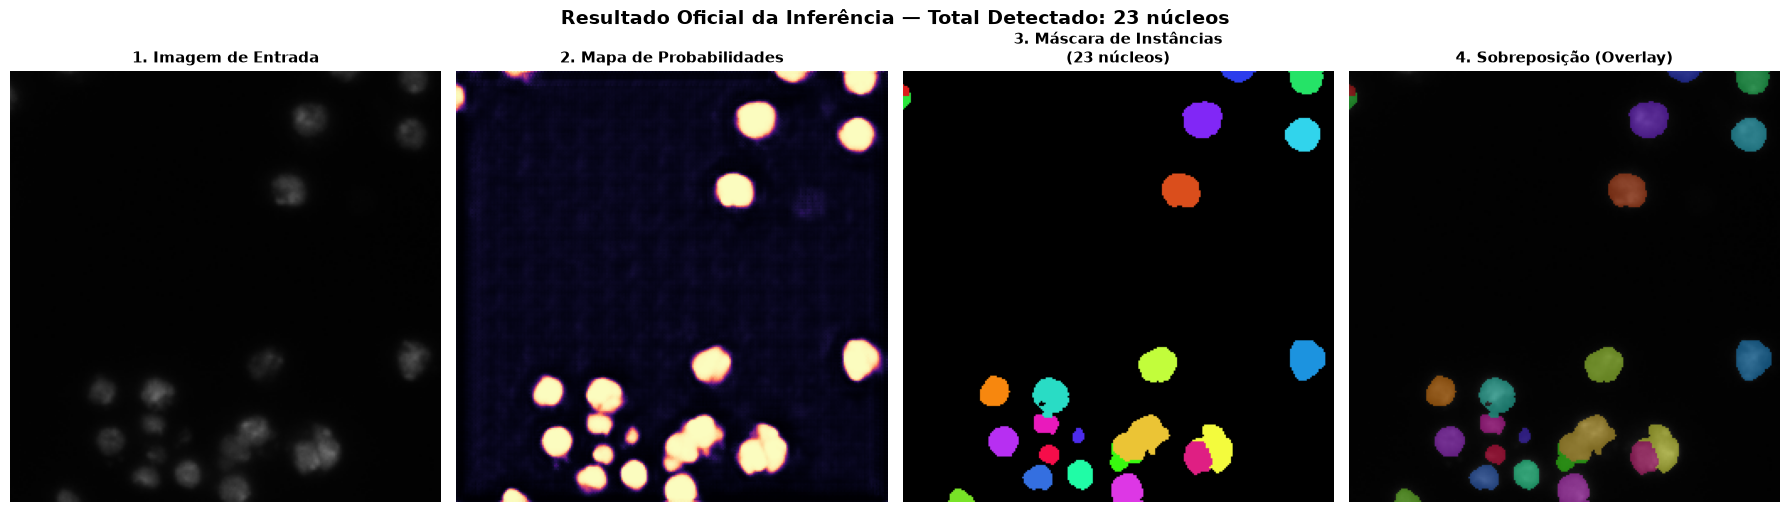

In [8]:
# Altere o caminho abaixo para qualquer imagem que desejar testar:
sample_image_path = "../data/raw/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png"

result = predict_instances(sample_image_path, model=model)

print("=" * 70)
print(f"IMAGEM PROCESSADA: {os.path.basename(sample_image_path)}")
print(f"CONTAGEM TOTAL DE NÚCLEOS DETECTADOS: {result['count']} núcleos")
print("=" * 70)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(result["original_image"])
axes[0].set_title("1. Imagem de Entrada", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(result["probability_map"], cmap="magma")
axes[1].set_title("2. Mapa de Probabilidades", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(result["colored_mask"])
axes[2].set_title(f"3. Máscara de Instâncias\n({result['count']} núcleos)", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(result["overlay"])
axes[3].set_title("4. Sobreposição (Overlay)", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle(f"Resultado Oficial da Inferência — Total Detectado: {result['count']} núcleos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()